## Block 1：配置参数
每次调试只需改这里，其他 Block 无需修改。

In [ ]:
import torch
import numpy as np

# ── 路径配置 ────────────────────────────────────────────────
MODEL_PATH            = r"H:\limr\project\urine\result\classification_model\UR_SingleCell_seed300_v3\train_val_models\DenseNet161\densenet161_fold_4.pth"
MALIGNANT_CELLS_DIR   = r"H:/limr/project/urine/rawdata/classification_model/UR_SingleCell/malignant"
BENIGN_CELLS_DIR      = r"H:/limr/project/urine/rawdata/classification_model/UR_SingleCell/benign"

# 候选域：阳性 & 阴性文件夹（与 pipeline.py 完全一致）
# POSITIVE_FOLDER_PATH  = r"H:\limr\project\urine\result\binary_infer\sample31\single_cell"   # 每个子文件夹是一个阳性病人
# NEGATIVE_FOLDER_PATH  = r"H:\limr\project\urine\result\binary_infer\sample31\test"   # 每个子文件夹是一个阴性病人

# BASE_SAVE_DIR         = r"H:\limr\project\urine\result\clustering\fp_diagnostic_avoid_ratio_v3"

POSITIVE_FOLDER_PATH  = r"H:\limr\project\urine\result\binary_infer\8malignant\single_cell"   # 每个子文件夹是一个阳性病人
NEGATIVE_FOLDER_PATH  = r"H:\limr\project\urine\result\binary_infer\sample31\test"   # 每个子文件夹是一个阴性病人

BASE_SAVE_DIR         = r"H:\limr\project\urine\result\clustering\fp_diagnostic_avoid_ratio_8malignant_v3"



# ── 模型配置 ────────────────────────────────────────────────
MODEL_TYPE            = "DenseNet161"
FEATURE_LAYER         = "penultimate"
MEAN                  = [0.5918, 0.5688, 0.7202]
STD                   = [0.2469, 0.2356, 0.1270]

# ── 聚类配置 ────────────────────────────────────────────────
REFERENCE_K           = 10
MAX_CANDIDATE_K       = 20
PCA_DIM               = 32
BATCH_SIZE            = 16
NUM_WORKERS           = 0
CELL_SIZE_WEIGHT      = 1.0

# ── 恶性簇索引 & 匹配规则 ────────────────────────────────────
MALIGNANT_REF_CLUSTERS = [8, 7, 1]

# MATCHING_RULES = [
#     # Rule1: 优先识别 R8 主导的恶性簇
#     # avoid_absolute=0.65 → 卡掉良性（avoid最小0.66），
#     # 但 wwjun_p2/C1(R7=0.84)、wwjun_p1/C0(R7=0.80) 会被误杀
#     # 所以不能用 avoid_absolute，改为提高 threshold_target
#     {
#         "target"                  : 8,
#         "avoid"                   : [7, 1],
#         "threshold_target"        : 0.82,   # 良性R8最高0.85，恶性R8最低0.75
#                                             # 0.82可保留xxqin/hqguo/wwjun_p1/C0，
#                                             # 放弃xdlian(R8=0.75)和wwjun_p1/C1(R8=0.75)
#         "threshold_ratio"         : 3,
#         "threshold_avoid_absolute": None,   # 不用，避免误杀
#     },
#     # Rule2: 识别 R7 主导的恶性簇（xdlian 的情况）
#     {
#         "target"                  : 7,
#         "avoid"                   : [8, 1],
#         "threshold_target"        : 0.80,   # xdlian R7=0.82，良性R7最高0.85
#         "threshold_ratio"         : 3,
#         "threshold_avoid_absolute": 0.76,   # R8不能超过0.76（xdlian R8=0.75刚好通过）
#                                             # 良性 R8 最低 0.73，大部分被卡掉
#     },
#     # Rule3: 识别 R1 主导的恶性簇（wwjun_p2/C4 的情况）
#     {
#         "target"                  : 1,
#         "avoid"                   : [8, 7],
#         "threshold_target"        : 0.90,   # wwjun_p2/C4 R1=0.93，良性R1最高0.78
#         "threshold_ratio"         : 3,
#         "threshold_avoid_absolute": None,
#     },
# ]

MATCHING_RULES = [
    # Rule1: 优先识别 R8 主导的恶性簇
    # avoid_absolute=0.65 → 卡掉良性（avoid最小0.66），
    # 但 wwjun_p2/C1(R7=0.84)、wwjun_p1/C0(R7=0.80) 会被误杀
    # 所以不能用 avoid_absolute，改为提高 threshold_target
    {
        "target"                  : 8,
        "avoid"                   : [7, 1],
        "threshold_target"        : 0.82,   # 良性R8最高0.85，恶性R8最低0.75
                                            # 0.82可保留xxqin/hqguo/wwjun_p1/C0，
                                            # 放弃xdlian(R8=0.75)和wwjun_p1/C1(R8=0.75)
        "threshold_ratio"         : 3,
        "threshold_avoid_ratio": None,   # 不用，避免误杀
    },
    # Rule2: 识别 R7 主导的恶性簇（xdlian 的情况）
    {
        "target"                  : 7,
        "avoid"                   : [8, 1],
        "threshold_target"        : 0.80,   # xdlian R7=0.82，良性R7最高0.85
        "threshold_ratio"         : 3,
        "threshold_avoid_ratio": 0.9,   
    },
    # Rule3: 识别 R1 主导的恶性簇（wwjun_p2/C4 的情况）
    {
        "target"                  : 1,
        "avoid"                   : [8, 7],
        "threshold_target"        : 0.90,   # wwjun_p2/C4 R1=0.93，良性R1最高0.78
        "threshold_ratio"         : 3,
        "threshold_avoid_absolute": None,
    },
]


# ── 【核心调参区】细胞级筛选参数 ─────────────────────────────
# 层1：细胞与最佳恶性参考簇的相似度必须 >= 该值
CELL_THRESHOLD_TARGET = 0.5

# 层2：细胞与最佳恶性参考簇的相似度，必须 >= 所有良性参考簇相似度的 N 倍
#      （良性簇 = 不在 MALIGNANT_REF_CLUSTERS 里的所有参考簇）
CELL_THRESHOLD_RATIO  = 3.0

# 是否保存被拒绝的细胞图片（调试时建议开启，正式跑时可关闭节省空间）
SAVE_REJECTED = True

# 随机种子
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("✅ Block 1 配置完成")
print(f"   恶性参考簇              : {MALIGNANT_REF_CLUSTERS}")
print(f"   细胞筛选 层1 threshold_target : {CELL_THRESHOLD_TARGET}")
print(f"   细胞筛选 层2 threshold_ratio  : {CELL_THRESHOLD_RATIO}")
print(f"   保存被拒绝细胞          : {SAVE_REJECTED}")


✅ Block 1 配置完成
   恶性参考簇              : [8, 7, 1]
   细胞筛选 层1 threshold_target : 0.5
   细胞筛选 层2 threshold_ratio  : 3.0
   保存被拒绝细胞          : True


## Block 2：导入依赖 & 初始化模型
只需运行一次。

In [7]:
import os
import shutil
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
from tqdm import tqdm

from cross_cluster_matching.models.models import get_model_and_transform
from cross_cluster_matching.data.data_utils import (
    collect_reference_data, collect_image_paths,
    CellImageDataset, extract_patient_id
)
from cross_cluster_matching.models.feature_extractor import extract_features_with_cell_size
from cross_cluster_matching.clustering.K_optimizer import optimize_k_for_candidate_clustering
from cross_cluster_matching.clustering.calculate_consensus_score import calculate_consensus_score
# from cross_cluster_matching.clustering.matching_rule_application import (
#     identify_matching_clusters, check_matching_rules
# )
# from cross_cluster_matching.clustering.matching_rule_application import (
#     identify_matching_clusters
# )
from cross_cluster_matching.visualization.visualization import (
    count_non_background_pixels,
    visualize_all_clusters_without_images,
    visualize_all_clusters_without_images_1,
    improved_visualize_clusters_with_images,
    visualize_matching_clusters,
    analyze_cluster_composition,
    plot_similarity_heatmap,
    visualize_filtered_clusters
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, transform, _ = get_model_and_transform(
    MODEL_TYPE, device, MODEL_PATH, mean=MEAN, std=STD
)
print(f"✅ Block 2 模型加载完成，使用设备: {device}")


DenseNet161模型权重加载成功！
✅ Block 2 模型加载完成，使用设备: cuda


## Block 3：处理参考域
只需运行一次，结果供所有病人复用。

In [8]:
print("======= 处理参考细胞 =======")

ref_paths, ref_sources = collect_reference_data(MALIGNANT_CELLS_DIR, BENIGN_CELLS_DIR)

ref_sizes = np.log1p([
    count_non_background_pixels(p)
    for p in tqdm(ref_paths, desc="Ref Sizes")
])

ref_loader = DataLoader(
    CellImageDataset(ref_paths, transform=transform, source_labels=ref_sources),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)
ref_feats, ref_sources, ref_paths = extract_features_with_cell_size(
    model, ref_loader, device, ref_sizes, FEATURE_LAYER, CELL_SIZE_WEIGHT
)

# PCA & KMeans
pca = PCA(n_components=min(PCA_DIM, ref_feats.shape[0], ref_feats.shape[1]))
ref_norm = normalize(pca.fit_transform(ref_feats))

kmeans_ref = KMeans(n_clusters=REFERENCE_K, random_state=SEED).fit(ref_norm)
ref_results = {
    "features"       : ref_norm,
    "labels"         : kmeans_ref.labels_,
    "source_labels"  : ref_sources,
    "image_paths"    : ref_paths,
    "cluster_centers": kmeans_ref.cluster_centers_,
    "n_clusters"     : REFERENCE_K,
    "pca"            : pca,
}

# 参考域可视化
ref_vis_dir = os.path.join(BASE_SAVE_DIR, f"reference_visualization_pca{PCA_DIM}")
os.makedirs(ref_vis_dir, exist_ok=True)

reference_umap = visualize_all_clusters_without_images(
    ref_results["features"], ref_results["labels"],
    ref_results["source_labels"], "Reference", ref_vis_dir
)
reference_umap_1 = visualize_all_clusters_without_images_1(
    ref_results["features"], ref_results["labels"],
    ref_results["source_labels"], "Reference", ref_vis_dir
)
improved_visualize_clusters_with_images(
    ref_results["features"], ref_results["labels"],
    ref_results["source_labels"], ref_results["image_paths"],
    "Reference", ref_vis_dir, ref_sizes
)
analyze_cluster_composition(
    ref_results["labels"], ref_results["source_labels"],
    ref_results["image_paths"], "Reference", ref_vis_dir
)

print(f"✅ Block 3 参考域处理完成，共 {len(ref_paths)} 个细胞，{REFERENCE_K} 个簇")
print(f"   参考域可视化保存至: {ref_vis_dir}")


======= 处理参考细胞 =======


提取特征: 100%|██████████| 125/125 [00:05<00:00, 21.27it/s]
c:\Users\ROG\.conda\envs\learn\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\ROG\.conda\envs\learn\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\ROG\.conda\envs\learn\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


为Reference创建不带缩略图的全局UMAP可视化...
  完成Reference的不带缩略图的全局可视化
为Reference创建不带缩略图的全局UMAP可视化...


c:\Users\ROG\.conda\envs\learn\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  完成Reference的不带缩略图的全局可视化
为Reference的每个簇创建可视化...
  聚类 0 有213个样本，使用UMAP降维


...

  聚类 7 有267个样本，使用UMAP降维


c:\Users\ROG\.conda\envs\learn\lib\site-packages\umap\umap_.py:1401: RuntimeWarning: divide by zero encountered in power
  return 1.0 / (1.0 + a * x ** (2 * b))
c:\Users\ROG\.conda\envs\learn\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  聚类 8 有155个样本，使用UMAP降维


c:\Users\ROG\.conda\envs\learn\lib\site-packages\umap\umap_.py:1401: RuntimeWarning: divide by zero encountered in power
  return 1.0 / (1.0 + a * x ** (2 * b))
c:\Users\ROG\.conda\envs\learn\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  聚类 9 有208个样本，使用UMAP降维
  完成Reference的可视化
聚类组成摘要已保存到: H:\limr\project\urine\result\clustering\fp_diagnostic_avoid_ratio_v3\reference_visualization_pca32\Reference_cluster_composition.csv
✅ Block 3 参考域处理完成，共 1997 个细胞，10 个簇
   参考域可视化保存至: H:\limr\project\urine\result\clustering\fp_diagnostic_avoid_ratio_v3\reference_visualization_pca32


## Block 4：定义增强版 `save_matched_cells_v2`
**核心改动**：在原 argmax 判断基础上新增两层细胞级筛选。只需运行一次。

### 采用threshold_avoid_ratio  参数

In [11]:
def check_matching_rules(
    similarities, 
    ref_idx_target, 
    ref_idx_avoid, 
    threshold_target, 
    threshold_avoid_others=None, 
    threshold_ratio=None,
    threshold_avoid_ratio=None,   # ← 改：absolute → ratio（相对比值上限）
):
    if similarities[ref_idx_target] < threshold_target:
        return False
    
    avoid_indices = ref_idx_avoid if isinstance(ref_idx_avoid, list) else [ref_idx_avoid]
    
    # ── avoid 簇相对比值检查 ─────────────────────────────────────
    # avoid恶性簇相似度 / target相似度 不能超过 threshold_avoid_ratio
    if threshold_avoid_ratio is not None:
        best_sim = similarities[ref_idx_target]
        if best_sim > 0 and any(
            similarities[i] / best_sim >= threshold_avoid_ratio
            for i in avoid_indices
        ):
            return False
    # ────────────────────────────────────────────────────────────
    
    other_indices = [
        i for i in range(len(similarities)) 
        if i != ref_idx_target and i not in avoid_indices
    ]
    
    if threshold_ratio:
        limit = similarities[ref_idx_target] / threshold_ratio
        if any(similarities[i] >= limit for i in other_indices):
            return False
            
    if threshold_avoid_others:
        if any(similarities[i] >= threshold_avoid_others for i in other_indices):
            return False
            
    return True

def identify_matching_clusters(candidate_centers, reference_centers, rules):    
    similarity_matrix = cosine_similarity(candidate_centers, reference_centers)
    rule_clusters = [[] for _ in rules]

    for i, sims in enumerate(similarity_matrix):
        for rule_idx, rule in enumerate(rules):
            matched = check_matching_rules(
                sims,
                ref_idx_target=rule["target"],
                ref_idx_avoid=rule["avoid"],
                threshold_target=rule["threshold_target"],
                threshold_avoid_others=rule.get("threshold_avoid_others"),
                threshold_ratio=rule.get("threshold_ratio"),
                threshold_avoid_ratio  = rule.get("threshold_avoid_ratio"),
            )
            if matched:
                rule_clusters[rule_idx].append(i)
                break  # 满足前面规则后不再判断后续规则

    return (*rule_clusters, similarity_matrix)

### 采用绝对值参数

In [ ]:
# 修改 check_matching_rules，增加 avoid 绝对上限
def check_matching_rules(
    similarities, 
    ref_idx_target, 
    ref_idx_avoid, 
    threshold_target, 
    threshold_avoid_others=None, 
    threshold_ratio=None,
    threshold_avoid_absolute=None,   # ← 新增：avoid簇的绝对上限
):
    if similarities[ref_idx_target] < threshold_target:
        return False
    
    avoid_indices = ref_idx_avoid if isinstance(ref_idx_avoid, list) else [ref_idx_avoid]
    
    # ── 新增：avoid 簇绝对上限检查 ──────────────────────────────
    # 如果与任意 avoid 簇的相似度超过阈值，说明不够专一，拒绝
    if threshold_avoid_absolute is not None:
        if any(similarities[i] >= threshold_avoid_absolute for i in avoid_indices):
            return False
    # ────────────────────────────────────────────────────────────
    
    other_indices = [
        i for i in range(len(similarities)) 
        if i != ref_idx_target and i not in avoid_indices
    ]
    
    if threshold_ratio:
        limit = similarities[ref_idx_target] / threshold_ratio
        if any(similarities[i] >= limit for i in other_indices):
            return False
            
    if threshold_avoid_others:
        if any(similarities[i] >= threshold_avoid_others for i in other_indices):
            return False
            
    return True

### 单细胞过滤：采用threshold_avoid_ratio参数

In [12]:
def _copy_rejected(src_path, rejected_dir, layer_tag, idx):
    """辅助函数：复制被拒绝的细胞图像到 rejected_dir"""
    os.makedirs(rejected_dir, exist_ok=True)
    filename = os.path.basename(src_path)
    new_name = f"{layer_tag}_idx{idx}_{filename}"
    shutil.copy(src_path, os.path.join(rejected_dir, new_name))


def save_matched_cells_v2(
    indices,
    image_paths,
    labels,
    cell_sim_matrix,
    rule_type,
    save_dirs,
    target_ref_indices,
    threshold_target=0.5,
    threshold_ratio=3.0,
    threshold_avoid_ratio=None,  # 新增：avoid恶性簇 / 最佳恶性簇 的比值上限
                                 # None  = 跳过层3（单恶性簇项目无需设置）
                                 # 推荐值：0.75（适用于本项目）
    save_rejected=False,
    rejected_dir=None,
):
    """
    增强版细胞级筛选（四层过滤）。

    Layer 0 - Argmax检查（原逻辑保留）：
        argmax(cell_sim_vec) 必须落在 target_ref_indices 里，
        否则说明该细胞最像某个良性参考簇，直接拒绝。

    Layer 1 - 门槛检查：
        与最佳恶性参考簇的相似度 >= threshold_target。
        确保细胞与恶性簇有足够强的相似性。

    Layer 2 - 良性专一性检查：
        最佳恶性簇相似度 >= 所有良性参考簇最大相似度 × threshold_ratio。
        良性簇 = 不在 target_ref_indices 里的所有参考簇。
        注意：不惩罚"同时像多个恶性簇"的细胞，只和良性簇比。

    Layer 3 - 恶性互斥性检查（新增，可选）：
        其余恶性簇的最大相似度 / 最佳恶性簇相似度 < threshold_avoid_ratio。
        用于过滤"同时激活多个恶性簇"的假阳性细胞。
        仅当 threshold_avoid_ratio 不为 None 且 target_ref_indices >= 2 时生效。

    参数
    ----
    indices              : list[int]    待检查的细胞索引列表
    image_paths          : list[str]    每个细胞对应的图像路径
    labels               : list[int]    每个细胞的聚类标签（单细胞模式下全为0）
    cell_sim_matrix      : ndarray      shape=(n_cells, n_ref)，细胞与参考簇的余弦相似度矩阵
    rule_type            : str          规则名称，如 'rule1'/'rule2'，用于文件命名
    save_dirs            : dict         {'rule_dir': ..., 'total_dir': ...}
    target_ref_indices   : list[int]    恶性参考簇索引列表，如 [1, 4]
    threshold_target     : float        层1阈值，最佳恶性簇相似度下限，默认 0.5
    threshold_ratio      : float        层2阈值，恶性/良性比值下限，默认 3.0
    threshold_avoid_ratio: float|None   层3阈值，avoid恶性簇占最佳恶性簇的比值上限
                                        None=跳过层3；推荐值 0.75
    save_rejected        : bool         是否保存被拒绝的细胞图像，默认 False
    rejected_dir         : str|None     被拒绝细胞的保存目录

    返回
    ----
    count             : int         通过筛选的细胞数量
    processed_indices : list[int]   通过筛选的细胞索引列表
    stats             : dict        详细统计信息
    """
    count = 0
    processed_indices = []

    stats = {
        "total"            : len(indices),
        "passed"           : 0,
        "rejected_argmax"  : 0,
        "rejected_layer1"  : 0,
        "rejected_layer2"  : 0,
        "rejected_layer3"  : 0,        # 新增
        "rejection_details": [],
        "_all_indices"     : indices,  # 保留供分布图使用
    }

    n_ref          = cell_sim_matrix.shape[1]
    benign_indices = [i for i in range(n_ref) if i not in target_ref_indices]

    for idx in indices:
        cell_sim_vec = cell_sim_matrix[idx]

        # ══════════════════════════════════════════════════════
        # Layer 0：Argmax 检查（原逻辑）
        # ══════════════════════════════════════════════════════
        most_similar_ref = int(np.argmax(cell_sim_vec))
        if most_similar_ref not in target_ref_indices:
            stats["rejected_argmax"] += 1
            stats["rejection_details"].append({
                "idx"   : idx,
                "path"  : image_paths[idx],
                "reason": f"argmax=R{most_similar_ref} 不在恶性簇 {target_ref_indices} 里",
                "layer" : 0,
            })
            if save_rejected and rejected_dir:
                _copy_rejected(image_paths[idx], rejected_dir, "L0", idx)
            continue

        # ── 找最佳恶性簇（后续层共用）────────────────────────
        mal_sims     = cell_sim_vec[target_ref_indices]
        best_mal_sim = float(mal_sims.max())
        best_mal_idx = target_ref_indices[int(mal_sims.argmax())]

        # ══════════════════════════════════════════════════════
        # Layer 1：门槛检查
        # ══════════════════════════════════════════════════════
        if best_mal_sim < threshold_target:
            stats["rejected_layer1"] += 1
            stats["rejection_details"].append({
                "idx"   : idx,
                "path"  : image_paths[idx],
                "reason": (f"层1: 恶性相似度 {best_mal_sim:.3f} "
                           f"< threshold_target {threshold_target}"),
                "layer" : 1,
            })
            if save_rejected and rejected_dir:
                _copy_rejected(image_paths[idx], rejected_dir, "L1", idx)
            continue

        # ══════════════════════════════════════════════════════
        # Layer 2：良性专一性检查
        # ══════════════════════════════════════════════════════
        if benign_indices:
            ben_sims    = cell_sim_vec[benign_indices]
            max_ben_sim = float(ben_sims.max())
            limit       = best_mal_sim / threshold_ratio

            if max_ben_sim >= limit:
                stats["rejected_layer2"] += 1
                stats["rejection_details"].append({
                    "idx"   : idx,
                    "path"  : image_paths[idx],
                    "reason": (f"层2: 良性最大相似度 {max_ben_sim:.3f} "
                               f">= limit {limit:.3f} "
                               f"(恶性 {best_mal_sim:.3f} / ratio {threshold_ratio})"),
                    "layer" : 2,
                })
                if save_rejected and rejected_dir:
                    _copy_rejected(image_paths[idx], rejected_dir, "L2", idx)
                continue

        # ══════════════════════════════════════════════════════
        # Layer 3：恶性互斥性检查（可选）
        # 语义：其余恶性簇不能太接近最佳恶性簇
        # 仅当 threshold_avoid_ratio 不为 None 且存在多个恶性簇时生效
        # ══════════════════════════════════════════════════════
        if threshold_avoid_ratio is not None and len(target_ref_indices) >= 2:
            # 取除最佳恶性簇之外，其余恶性簇的最大相似度
            avoid_mal_indices = [i for i in target_ref_indices if i != best_mal_idx]
            avoid_mal_sim     = float(cell_sim_vec[avoid_mal_indices].max())

            # 计算比值：avoid恶性簇 / 最佳恶性簇
            ratio_avoid = avoid_mal_sim / best_mal_sim if best_mal_sim > 0 else 999.0

            if ratio_avoid >= threshold_avoid_ratio:
                stats["rejected_layer3"] += 1
                stats["rejection_details"].append({
                    "idx"   : idx,
                    "path"  : image_paths[idx],
                    "reason": (f"层3: avoid恶性簇相似度 {avoid_mal_sim:.3f} / "
                               f"最佳恶性簇 {best_mal_sim:.3f} "
                               f"= ratio {ratio_avoid:.3f} "
                               f">= threshold_avoid_ratio {threshold_avoid_ratio}"),
                    "layer" : 3,
                })
                if save_rejected and rejected_dir:
                    _copy_rejected(image_paths[idx], rejected_dir, "L3", idx)
                continue

        # ══════════════════════════════════════════════════════
        # 全部通过 → 保存细胞
        # ══════════════════════════════════════════════════════
        src_path      = image_paths[idx]
        filename      = os.path.basename(src_path)
        cluster_label = labels[idx]
        prefix        = (f"ref{best_mal_idx}_sim{best_mal_sim:.4f}"
                         f"_{rule_type}_cluster{cluster_label}")
        new_name      = f"{prefix}_{filename}"

        shutil.copy(src_path, os.path.join(save_dirs["rule_dir"],  new_name))
        shutil.copy(src_path, os.path.join(save_dirs["total_dir"], new_name))

        count += 1
        processed_indices.append(idx)
        stats["passed"] += 1

    return count, processed_indices, stats



def print_cell_stats(rule_name, stats):
    """打印单条规则的细胞筛选统计"""
    total = stats["total"]
    if total == 0:
        print(f"  [{rule_name}] 无细胞输入，跳过")
        return
    print(f"  [{rule_name}] 输入 {total} 个细胞：")
    print(f"    ✅ 通过保留        : {stats['passed']:4d}  ({stats['passed']/total*100:5.1f}%)")
    print(f"    ❌ argmax 非恶性簇 : {stats['rejected_argmax']:4d}  ({stats['rejected_argmax']/total*100:5.1f}%)")
    print(f"    ❌ 层1 恶性度不足  : {stats['rejected_layer1']:4d}  ({stats['rejected_layer1']/total*100:5.1f}%)")
    print(f"    ❌ 层2 良性簇太像  : {stats['rejected_layer2']:4d}  ({stats['rejected_layer2']/total*100:5.1f}%)")
    print(f"    ❌ 层3 avoid簇太近  : {stats['rejected_layer3']:4d}  ({stats['rejected_layer3']/total*100:5.1f}%)")


print("✅ Block 4 save_matched_cells_v2 定义完成")

✅ Block 4 save_matched_cells_v2 定义完成


### 单细胞过滤：采用原参数

In [ ]:

def _copy_rejected(src_path, rejected_dir, tag, idx):
    """辅助：把被拒绝的细胞复制到调试目录"""
    os.makedirs(rejected_dir, exist_ok=True)
    filename = os.path.basename(src_path)
    shutil.copy(src_path, os.path.join(rejected_dir, f"rejected_{tag}_{idx}_{filename}"))


def save_matched_cells_v2(
    indices,
    image_paths,
    labels,
    cell_sim_matrix,
    rule_type,
    save_dirs,
    target_ref_indices,
    threshold_target=0.5,
    threshold_ratio=3.0,
    save_rejected=False,
    rejected_dir=None,
):
    """
    增强版细胞级筛选。

    原逻辑（保留）：
        argmax(cell_sims) 必须在 target_ref_indices 里

    新增层1（门槛层）：
        与最佳恶性参考簇的相似度 >= threshold_target

    新增层2（专一层）：
        最佳恶性簇相似度 >= 所有良性参考簇相似度 * threshold_ratio
        （良性簇 = 不在 target_ref_indices 里的所有参考簇）
        注意：不惩罚"同时像多个恶性簇"的细胞
    """
    count = 0
    processed_indices = []

    stats = {
        "total"            : len(indices),
        "passed"           : 0,
        "rejected_argmax"  : 0,
        "rejected_layer1"  : 0,
        "rejected_layer2"  : 0,
        "rejection_details": [],
        "_all_indices"     : indices,   # 保留供 Block 6 分布图使用
    }

    n_ref          = cell_sim_matrix.shape[1]
    benign_indices = [i for i in range(n_ref) if i not in target_ref_indices]

    for idx in indices:
        cell_sim_vec = cell_sim_matrix[idx]

        # ── 原逻辑：argmax 必须在恶性簇里 ──────────────────────
        most_similar_ref = int(np.argmax(cell_sim_vec))
        if most_similar_ref not in target_ref_indices:
            stats["rejected_argmax"] += 1
            stats["rejection_details"].append({
                "idx"   : idx,
                "path"  : image_paths[idx],
                "reason": f"argmax=R{most_similar_ref} 不在恶性簇 {target_ref_indices} 里",
                "layer" : 0,
            })
            if save_rejected and rejected_dir:
                _copy_rejected(image_paths[idx], rejected_dir, "L0", idx)
            continue

        # ── 找最佳恶性簇 ────────────────────────────────────────
        mal_sims     = cell_sim_vec[target_ref_indices]
        best_mal_sim = float(mal_sims.max())
        best_mal_idx = target_ref_indices[int(mal_sims.argmax())]

        # ── 新增层1：门槛检查 ────────────────────────────────────
        if best_mal_sim < threshold_target:
            stats["rejected_layer1"] += 1
            stats["rejection_details"].append({
                "idx"   : idx,
                "path"  : image_paths[idx],
                "reason": f"层1: 恶性相似度 {best_mal_sim:.3f} < {threshold_target}",
                "layer" : 1,
            })
            if save_rejected and rejected_dir:
                _copy_rejected(image_paths[idx], rejected_dir, "L1", idx)
            continue

        # ── 新增层2：专一性检查（只和良性簇比）──────────────────
        if benign_indices:
            ben_sims    = cell_sim_vec[benign_indices]
            max_ben_sim = float(ben_sims.max())
            limit       = best_mal_sim / threshold_ratio

            if max_ben_sim >= limit:
                stats["rejected_layer2"] += 1
                stats["rejection_details"].append({
                    "idx"   : idx,
                    "path"  : image_paths[idx],
                    "reason": (f"层2: 良性最大相似度 {max_ben_sim:.3f} "
                               f">= limit {limit:.3f} "
                               f"(恶性{best_mal_sim:.3f} / ratio{threshold_ratio})"),
                    "layer" : 2,
                })
                if save_rejected and rejected_dir:
                    _copy_rejected(image_paths[idx], rejected_dir, "L2", idx)
                continue

        # ── 全部通过，保存细胞 ───────────────────────────────────
        src_path      = image_paths[idx]
        filename      = os.path.basename(src_path)
        cluster_label = labels[idx]
        prefix   = f"ref{best_mal_idx}_sim{best_mal_sim:.4f}_{rule_type}_cluster{cluster_label}"
        new_name      = f"{prefix}_{filename}"

        shutil.copy(src_path, os.path.join(save_dirs["rule_dir"],  new_name))
        shutil.copy(src_path, os.path.join(save_dirs["total_dir"], new_name))

        count += 1
        processed_indices.append(idx)
        stats["passed"] += 1

    return count, processed_indices, stats


def print_cell_stats(rule_name, stats):
    """打印单条规则的细胞筛选统计"""
    total = stats["total"]
    if total == 0:
        print(f"  [{rule_name}] 无细胞输入，跳过")
        return
    print(f"  [{rule_name}] 输入 {total} 个细胞：")
    print(f"    ✅ 通过保留        : {stats['passed']:4d}  ({stats['passed']/total*100:5.1f}%)")
    print(f"    ❌ argmax 非恶性簇 : {stats['rejected_argmax']:4d}  ({stats['rejected_argmax']/total*100:5.1f}%)")
    print(f"    ❌ 层1 恶性度不足  : {stats['rejected_layer1']:4d}  ({stats['rejected_layer1']/total*100:5.1f}%)")
    print(f"    ❌ 层2 良性簇太像  : {stats['rejected_layer2']:4d}  ({stats['rejected_layer2']/total*100:5.1f}%)")


print("✅ Block 4 save_matched_cells_v2 定义完成")


✅ Block 4 save_matched_cells_v2 定义完成


## Block 5：批量处理所有病人
与 `pipeline.py` 逻辑完全一致，同时处理阳性 & 阴性文件夹下的所有病人。

> **调参时**：只需修改 Block 1 的 `CELL_THRESHOLD_TARGET` / `CELL_THRESHOLD_RATIO`，然后**重新运行 Block 5**，无需重跑 Block 2/3/4。


### 单细胞过滤：采用threshold_avoid_ratio参数

In [14]:
# 收集所有病人文件夹（与 pipeline.py 完全一致）
patient_folders = []
patient_folders.extend(
    [(entry.path, "positive") for entry in os.scandir(POSITIVE_FOLDER_PATH) if entry.is_dir()]
)
patient_folders.extend(
    [(entry.path, "negative") for entry in os.scandir(NEGATIVE_FOLDER_PATH) if entry.is_dir()]
)

print(f"共发现 {len(patient_folders)} 个病人文件夹")
print(f"  阳性: {sum(1 for _, s in patient_folders if s == 'positive')} 个")
print(f"  阴性: {sum(1 for _, s in patient_folders if s == 'negative')} 个")
print(f"  细胞筛选参数: threshold_target={CELL_THRESHOLD_TARGET}, threshold_ratio={CELL_THRESHOLD_RATIO}")
print()

n_rules            = len(MATCHING_RULES)
results_stats      = []
all_patient_stats  = {}

for folder, status in patient_folders:
    pid      = extract_patient_id(folder)
    save_dir = os.path.join(BASE_SAVE_DIR, pid)
    os.makedirs(save_dir, exist_ok=True)

    # ── 收集候选细胞 ────────────────────────────────────────────
    cand_paths = collect_image_paths(os.path.join(folder, "malignant_images"))
    if not cand_paths:
        print(f"  ⚠️  {pid}: 未找到细胞图像，跳过")
        continue

    cand_sources = [0] * len(cand_paths)
    cand_sizes   = np.log1p([count_non_background_pixels(p) for p in cand_paths])

    # ── 特征提取 ────────────────────────────────────────────────
    cand_loader = DataLoader(
        CellImageDataset(cand_paths, transform=transform, source_labels=cand_sources),
        batch_size=BATCH_SIZE, shuffle=False
    )
    cand_feats, _, cand_paths = extract_features_with_cell_size(
        model, cand_loader, device, cand_sizes, FEATURE_LAYER, CELL_SIZE_WEIGHT
    )

    # PCA Transform（复用参考域 pca，不重新 fit）
    cand_norm = normalize(pca.transform(cand_feats))

    # ── 动态初始化保存目录 ──────────────────────────────────────
    matched_counts     = [0] * n_rules
    dirs = {f"rule{i+1}": os.path.join(save_dir, f"rule{i+1}_matched_cells") for i in range(n_rules)}
    dirs["total"]      = os.path.join(save_dir, "matched_malignant_cells")
    for d in dirs.values():
        os.makedirs(d, exist_ok=True)

    patient_rule_stats  = {}
    passed_indices_dict = {}   # ← 改动1：新增，收集每条规则通过的细胞索引

    # ════════════════════════════════════════════════════════════
    # 聚类模式（细胞数 >= 32）
    # ════════════════════════════════════════════════════════════
    if len(cand_norm) >= 32:
        cand_results, best_k = optimize_k_for_candidate_clustering(
            cand_norm, cand_sources, cand_paths, ref_results,
            save_dir, pid, MAX_CANDIDATE_K, MALIGNANT_REF_CLUSTERS
        )
        if not cand_results:
            print(f"  ⚠️  {pid}: 聚类优化失败，跳过")
            continue

        # 保存聚类明细 CSV
        pd.DataFrame({
            "labels"     : cand_results["labels"],
            "image_paths": cand_results["image_paths"],
        }).to_csv(os.path.join(save_dir, "cluster_detail.csv"),
                  index=False, encoding="utf-8-sig")

        # 簇级相似度矩阵 & 匹配
        *rule_clusters_list, similarity_matrix = identify_matching_clusters(
            cand_results["cluster_centers"],
            ref_results["cluster_centers"],
            MATCHING_RULES
        )

        # 细胞级相似度矩阵
        cell_sims = cosine_similarity(cand_results["features"], ref_results["cluster_centers"])

        # ── 细胞级筛选（核心改动）──────────────────────────────
        for i, (rule, rule_clusters) in enumerate(zip(MATCHING_RULES, rule_clusters_list)):
            rule_name = f"rule{i+1}"
            indices   = [j for j, lbl in enumerate(cand_results["labels"]) if lbl in rule_clusters]

            rejected_dir_p = (
                os.path.join(save_dir, "rejected_cells_debug", rule_name)
                if SAVE_REJECTED else None
            )

            count, processed_indices, stats = save_matched_cells_v2(
                indices            = indices,
                image_paths        = cand_paths,
                labels             = cand_results["labels"],
                cell_sim_matrix    = cell_sims,
                rule_type          = rule_name,
                save_dirs          = {"rule_dir": dirs[rule_name], "total_dir": dirs["total"]},
                target_ref_indices = MALIGNANT_REF_CLUSTERS,
                threshold_target   = CELL_THRESHOLD_TARGET,
                threshold_ratio    = CELL_THRESHOLD_RATIO,
                threshold_avoid_ratio = rule.get("threshold_avoid_ratio", None),  # ← 新增这一行
                save_rejected      = SAVE_REJECTED,
                rejected_dir       = rejected_dir_p,
            )
            matched_counts[i]              = count
            patient_rule_stats[rule_name]  = stats
            passed_indices_dict[rule_name] = processed_indices   # ← 改动3：存入字典

        # ── 构建 matching_pairs & 可视化 ───────────────────────
        matching_pairs = []
        for rule, rule_clusters in zip(MATCHING_RULES, rule_clusters_list):
            for cand_idx in rule_clusters:
                matching_pairs.append(
                    (rule["target"], cand_idx, similarity_matrix[cand_idx, rule["target"]])
                )

        rule_matched_clusters = {
            f"rule{i+1}": clusters for i, clusters in enumerate(rule_clusters_list)
        }

        calculate_consensus_score(ref_results, cand_results, matching_pairs, save_dir)
        visualize_matching_clusters(
            ref_results, cand_results, matching_pairs,
            save_dir, reference_umap, rule_matched_clusters
        )
        visualize_all_clusters_without_images(
            cand_results["features"], cand_results["labels"],
            cand_results["source_labels"], pid, save_dir, reference_umap
        )
        improved_visualize_clusters_with_images(
            cand_results["features"], cand_results["labels"],
            cand_results["source_labels"], cand_paths, pid, save_dir, cand_sizes
        )
        visualize_filtered_clusters(
            ref_results, cand_results, matching_pairs, save_dir,
            rule_matched_clusters = rule_matched_clusters,
            target_ref_indices    = MALIGNANT_REF_CLUSTERS,
            passed_indices_dict   = passed_indices_dict,   # ← 改动4：传入通过索引
        )
        xlabel = [f"C{i}" for i in range(cand_results["n_clusters"])]
        ylabel = [f"R{i}" for i in range(ref_results["n_clusters"])]
        plot_similarity_heatmap(
            similarity_matrix.T, xlabel, ylabel,
            f"{pid} Similarity Matrix",
            os.path.join(save_dir, "similarity_heatmap.png")
        )

        all_patient_stats[pid] = {
            "status"            : status,
            "rule_stats"        : patient_rule_stats,
            "total_matched"     : sum(matched_counts),
            "cell_sims"         : cell_sims,
            "rule_clusters_list": rule_clusters_list,
            "cand_labels"       : cand_results["labels"],
        }

    # ════════════════════════════════════════════════════════════
    # 单细胞模式（细胞数 < 32）
    # ════════════════════════════════════════════════════════════
    else:
        cell_sims = cosine_similarity(cand_norm, ref_results["cluster_centers"])

        processed = set()
        for i, rule in enumerate(MATCHING_RULES):
            rule_name = f"rule{i+1}"
            indices   = [
                j for j, s in enumerate(cell_sims)
                if j not in processed and check_matching_rules(
                    s,
                    ref_idx_target         = rule["target"],
                    ref_idx_avoid          = rule["avoid"],
                    threshold_target       = rule["threshold_target"],
                    threshold_avoid_others = rule.get("threshold_avoid_others"),
                    threshold_ratio        = rule.get("threshold_ratio"),
                )
            ]

            rejected_dir_p = (
                os.path.join(save_dir, "rejected_cells_debug", rule_name)
                if SAVE_REJECTED else None
            )

            count, newly_processed, stats = save_matched_cells_v2(
                indices            = indices,
                image_paths        = cand_paths,
                labels             = [0] * len(cand_paths),
                cell_sim_matrix    = cell_sims,
                rule_type          = rule_name,
                save_dirs          = {"rule_dir": dirs[rule_name], "total_dir": dirs["total"]},
                target_ref_indices = MALIGNANT_REF_CLUSTERS,
                threshold_target   = CELL_THRESHOLD_TARGET,
                threshold_ratio    = CELL_THRESHOLD_RATIO,
                threshold_avoid_ratio = rule.get("threshold_avoid_ratio", None),  # ← 新增这一行
                save_rejected      = SAVE_REJECTED,
                rejected_dir       = rejected_dir_p,
            )
            matched_counts[i]             = count
            patient_rule_stats[rule_name] = stats
            processed.update(newly_processed)
            # 注意：单细胞模式下没有 visualize_filtered_clusters，无需收集 passed_indices_dict

        xlabel = [f"Cell{i}" for i in range(len(cell_sims))]
        ylabel = [f"R{i}" for i in range(ref_results["n_clusters"])]
        plot_similarity_heatmap(
            cell_sims.T, xlabel, ylabel,
            f"{pid} Cell Similarity Matrix",
            os.path.join(save_dir, "Cell_similarity_heatmap.png")
        )

        all_patient_stats[pid] = {
            "status"            : status,
            "rule_stats"        : patient_rule_stats,
            "total_matched"     : sum(matched_counts),
            "cell_sims"         : cell_sims,
            "rule_clusters_list": None,
            "cand_labels"       : None,
        }

    # ── 汇总统计 ────────────────────────────────────────────────
    total_matched = sum(matched_counts)
    stat = {
        "Patient_ID": pid,
        "Status"    : status,
        **{f"Rule{i+1}": matched_counts[i] for i in range(n_rules)},
        "Total"     : total_matched,
    }
    results_stats.append(stat)

    # ── 打印本病人汇总 ──────────────────────────────────────────
    print(f"{'─'*55}")
    print(f"  病人: {pid}  [{status.upper()}]  最终保留: {total_matched} 个细胞")
    for rule_name, stats in patient_rule_stats.items():
        print_cell_stats(rule_name, stats)

# ── 保存汇总 Excel ──────────────────────────────────────────
stats_df   = pd.DataFrame(results_stats)
excel_path = os.path.join(BASE_SAVE_DIR, "stats.xlsx")
stats_df.to_excel(excel_path, index=False)

print(f"\n{'='*55}")
print(f"✅ Block 5 批量处理完成，共处理 {len(results_stats)} 个病人")
print(f"   汇总统计已保存至: {excel_path}")
print()
print(stats_df.to_string(index=False))

共发现 31 个病人文件夹
  阳性: 31 个
  阴性: 0 个
  细胞筛选参数: threshold_target=0.5, threshold_ratio=3.0



提取特征: 100%|██████████| 5/5 [00:00<00:00,  8.77it/s]
c:\Users\ROG\.conda\envs\learn\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\ROG\.conda\envs\learn\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ROG\.conda\envs\learn\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\ROG\.conda\envs\learn\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarnin

  候选细胞数量为 80，开始优化k值...
  尝试k值: 2
  k=2 的加权评分: 0.6273
  尝试k值: 4
  k=4 的加权评分: 0.5965
  尝试k值: 6
  k=6 的加权评分: 0.5864
  尝试k值: 8
  k=8 的加权评分: 0.5813


c:\Users\ROG\.conda\envs\learn\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\ROG\.conda\envs\learn\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ROG\.conda\envs\learn\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\ROG\.conda\envs\learn\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows 

  尝试k值: 10
  k=10 的加权评分: 0.5685
  尝试k值: 12
  k=12 的加权评分: 0.5621


...

  聚类 0 有1000个样本，使用UMAP降维


c:\Users\ROG\.conda\envs\learn\lib\site-packages\umap\umap_.py:1401: RuntimeWarning: divide by zero encountered in power
  return 1.0 / (1.0 + a * x ** (2 * b))
c:\Users\ROG\.conda\envs\learn\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  聚类 1 有1000个样本，使用UMAP降维
  完成SH_xxqin_p1的可视化
为匹配的簇创建可视化（保持原始UMAP位置）...
计算细胞大小...


计算细胞大小: 100%|██████████| 5644/5644 [00:03<00:00, 1526.98it/s]
c:\Users\ROG\.conda\envs\learn\lib\site-packages\umap\umap_.py:1401: RuntimeWarning: divide by zero encountered in power
  return 1.0 / (1.0 + a * x ** (2 * b))
c:\Users\ROG\.conda\envs\learn\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\ROG\.conda\envs\learn\lib\site-packages\umap\umap_.py:1401: RuntimeWarning: divide by zero encountered in power
  return 1.0 / (1.0 + a * x ** (2 * b))
c:\Users\ROG\.conda\envs\learn\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  匹配簇可视化完成
  热图已保存至: H:\limr\project\urine\result\clustering\fp_diagnostic_avoid_ratio_v3\SH_xxqin_p1\similarity_heatmap.png
───────────────────────────────────────────────────────
  病人: SH_xxqin_p1  [POSITIVE]  最终保留: 4500 个细胞
  [rule1] 输入 5644 个细胞：
    ✅ 通过保留        : 4500  ( 79.7%)
    ❌ argmax 非恶性簇 :    3  (  0.1%)
    ❌ 层1 恶性度不足  :   30  (  0.5%)
    ❌ 层2 良性簇太像  : 1111  ( 19.7%)
    ❌ 层3 avoid簇太近  :    0  (  0.0%)
  [rule2] 无细胞输入，跳过
  [rule3] 无细胞输入，跳过

✅ Block 5 批量处理完成，共处理 29 个病人
   汇总统计已保存至: H:\limr\project\urine\result\clustering\fp_diagnostic_avoid_ratio_v3\stats.xlsx

  Patient_ID   Status  Rule1  Rule2  Rule3  Total
   SH_561505 positive     32      0      0     32
   SH_561507 positive      0      0      0      0
   SH_561512 positive      0      0      0      0
   SH_562008 positive      0      0      0      0
   SH_562014 positive      0      0      0      0
   SH_562026 positive      0      0      0      0
   SH_562027 positive      0      0      0      0
   SH_562031 posi

### 原逻辑处理

In [5]:
# 收集所有病人文件夹（与 pipeline.py 完全一致）
patient_folders = []
patient_folders.extend(
    [(entry.path, "positive") for entry in os.scandir(POSITIVE_FOLDER_PATH) if entry.is_dir()]
)
patient_folders.extend(
    [(entry.path, "negative") for entry in os.scandir(NEGATIVE_FOLDER_PATH) if entry.is_dir()]
)

print(f"共发现 {len(patient_folders)} 个病人文件夹")
print(f"  阳性: {sum(1 for _, s in patient_folders if s == 'positive')} 个")
print(f"  阴性: {sum(1 for _, s in patient_folders if s == 'negative')} 个")
print(f"  细胞筛选参数: threshold_target={CELL_THRESHOLD_TARGET}, threshold_ratio={CELL_THRESHOLD_RATIO}")
print()

n_rules            = len(MATCHING_RULES)
results_stats      = []
all_patient_stats  = {}

for folder, status in patient_folders:
    pid      = extract_patient_id(folder)
    save_dir = os.path.join(BASE_SAVE_DIR, pid)
    os.makedirs(save_dir, exist_ok=True)

    # ── 收集候选细胞 ────────────────────────────────────────────
    cand_paths = collect_image_paths(os.path.join(folder, "malignant_images"))
    if not cand_paths:
        print(f"  ⚠️  {pid}: 未找到细胞图像，跳过")
        continue

    cand_sources = [0] * len(cand_paths)
    cand_sizes   = np.log1p([count_non_background_pixels(p) for p in cand_paths])

    # ── 特征提取 ────────────────────────────────────────────────
    cand_loader = DataLoader(
        CellImageDataset(cand_paths, transform=transform, source_labels=cand_sources),
        batch_size=BATCH_SIZE, shuffle=False
    )
    cand_feats, _, cand_paths = extract_features_with_cell_size(
        model, cand_loader, device, cand_sizes, FEATURE_LAYER, CELL_SIZE_WEIGHT
    )

    # PCA Transform（复用参考域 pca，不重新 fit）
    cand_norm = normalize(pca.transform(cand_feats))

    # ── 动态初始化保存目录 ──────────────────────────────────────
    matched_counts     = [0] * n_rules
    dirs = {f"rule{i+1}": os.path.join(save_dir, f"rule{i+1}_matched_cells") for i in range(n_rules)}
    dirs["total"]      = os.path.join(save_dir, "matched_malignant_cells")
    for d in dirs.values():
        os.makedirs(d, exist_ok=True)

    patient_rule_stats  = {}
    passed_indices_dict = {}   # ← 改动1：新增，收集每条规则通过的细胞索引

    # ════════════════════════════════════════════════════════════
    # 聚类模式（细胞数 >= 32）
    # ════════════════════════════════════════════════════════════
    if len(cand_norm) >= 32:
        cand_results, best_k = optimize_k_for_candidate_clustering(
            cand_norm, cand_sources, cand_paths, ref_results,
            save_dir, pid, MAX_CANDIDATE_K, MALIGNANT_REF_CLUSTERS
        )
        if not cand_results:
            print(f"  ⚠️  {pid}: 聚类优化失败，跳过")
            continue

        # 保存聚类明细 CSV
        pd.DataFrame({
            "labels"     : cand_results["labels"],
            "image_paths": cand_results["image_paths"],
        }).to_csv(os.path.join(save_dir, "cluster_detail.csv"),
                  index=False, encoding="utf-8-sig")

        # 簇级相似度矩阵 & 匹配
        *rule_clusters_list, similarity_matrix = identify_matching_clusters(
            cand_results["cluster_centers"],
            ref_results["cluster_centers"],
            MATCHING_RULES
        )

        # 细胞级相似度矩阵
        cell_sims = cosine_similarity(cand_results["features"], ref_results["cluster_centers"])

        # ── 细胞级筛选（核心改动）──────────────────────────────
        for i, rule_clusters in enumerate(rule_clusters_list):
            rule_name = f"rule{i+1}"
            indices   = [j for j, lbl in enumerate(cand_results["labels"]) if lbl in rule_clusters]

            rejected_dir_p = (
                os.path.join(save_dir, "rejected_cells_debug", rule_name)
                if SAVE_REJECTED else None
            )

            count, processed_indices, stats = save_matched_cells_v2(   # ← 改动2：接收 processed_indices
                indices            = indices,
                image_paths        = cand_paths,
                labels             = cand_results["labels"],
                cell_sim_matrix    = cell_sims,
                rule_type          = rule_name,
                save_dirs          = {"rule_dir": dirs[rule_name], "total_dir": dirs["total"]},
                target_ref_indices = MALIGNANT_REF_CLUSTERS,
                threshold_target   = CELL_THRESHOLD_TARGET,
                threshold_ratio    = CELL_THRESHOLD_RATIO,
                save_rejected      = SAVE_REJECTED,
                rejected_dir       = rejected_dir_p,
            )
            matched_counts[i]              = count
            patient_rule_stats[rule_name]  = stats
            passed_indices_dict[rule_name] = processed_indices   # ← 改动3：存入字典

        # ── 构建 matching_pairs & 可视化 ───────────────────────
        matching_pairs = []
        for rule, rule_clusters in zip(MATCHING_RULES, rule_clusters_list):
            for cand_idx in rule_clusters:
                matching_pairs.append(
                    (rule["target"], cand_idx, similarity_matrix[cand_idx, rule["target"]])
                )

        rule_matched_clusters = {
            f"rule{i+1}": clusters for i, clusters in enumerate(rule_clusters_list)
        }

        calculate_consensus_score(ref_results, cand_results, matching_pairs, save_dir)
        visualize_matching_clusters(
            ref_results, cand_results, matching_pairs,
            save_dir, reference_umap, rule_matched_clusters
        )
        visualize_all_clusters_without_images(
            cand_results["features"], cand_results["labels"],
            cand_results["source_labels"], pid, save_dir, reference_umap
        )
        improved_visualize_clusters_with_images(
            cand_results["features"], cand_results["labels"],
            cand_results["source_labels"], cand_paths, pid, save_dir, cand_sizes
        )
        visualize_filtered_clusters(
            ref_results, cand_results, matching_pairs, save_dir,
            rule_matched_clusters = rule_matched_clusters,
            target_ref_indices    = MALIGNANT_REF_CLUSTERS,
            passed_indices_dict   = passed_indices_dict,   # ← 改动4：传入通过索引
        )
        xlabel = [f"C{i}" for i in range(cand_results["n_clusters"])]
        ylabel = [f"R{i}" for i in range(ref_results["n_clusters"])]
        plot_similarity_heatmap(
            similarity_matrix.T, xlabel, ylabel,
            f"{pid} Similarity Matrix",
            os.path.join(save_dir, "similarity_heatmap.png")
        )

        all_patient_stats[pid] = {
            "status"            : status,
            "rule_stats"        : patient_rule_stats,
            "total_matched"     : sum(matched_counts),
            "cell_sims"         : cell_sims,
            "rule_clusters_list": rule_clusters_list,
            "cand_labels"       : cand_results["labels"],
        }

    # ════════════════════════════════════════════════════════════
    # 单细胞模式（细胞数 < 32）
    # ════════════════════════════════════════════════════════════
    else:
        cell_sims = cosine_similarity(cand_norm, ref_results["cluster_centers"])

        processed = set()
        for i, rule in enumerate(MATCHING_RULES):
            rule_name = f"rule{i+1}"
            indices   = [
                j for j, s in enumerate(cell_sims)
                if j not in processed and check_matching_rules(
                    s,
                    ref_idx_target         = rule["target"],
                    ref_idx_avoid          = rule["avoid"],
                    threshold_target       = rule["threshold_target"],
                    threshold_avoid_others = rule.get("threshold_avoid_others"),
                    threshold_ratio        = rule.get("threshold_ratio"),
                )
            ]

            rejected_dir_p = (
                os.path.join(save_dir, "rejected_cells_debug", rule_name)
                if SAVE_REJECTED else None
            )

            count, newly_processed, stats = save_matched_cells_v2(
                indices            = indices,
                image_paths        = cand_paths,
                labels             = [0] * len(cand_paths),
                cell_sim_matrix    = cell_sims,
                rule_type          = rule_name,
                save_dirs          = {"rule_dir": dirs[rule_name], "total_dir": dirs["total"]},
                target_ref_indices = MALIGNANT_REF_CLUSTERS,
                threshold_target   = CELL_THRESHOLD_TARGET,
                threshold_ratio    = CELL_THRESHOLD_RATIO,
                save_rejected      = SAVE_REJECTED,
                rejected_dir       = rejected_dir_p,
            )
            matched_counts[i]             = count
            patient_rule_stats[rule_name] = stats
            processed.update(newly_processed)
            # 注意：单细胞模式下没有 visualize_filtered_clusters，无需收集 passed_indices_dict

        xlabel = [f"Cell{i}" for i in range(len(cell_sims))]
        ylabel = [f"R{i}" for i in range(ref_results["n_clusters"])]
        plot_similarity_heatmap(
            cell_sims.T, xlabel, ylabel,
            f"{pid} Cell Similarity Matrix",
            os.path.join(save_dir, "Cell_similarity_heatmap.png")
        )

        all_patient_stats[pid] = {
            "status"            : status,
            "rule_stats"        : patient_rule_stats,
            "total_matched"     : sum(matched_counts),
            "cell_sims"         : cell_sims,
            "rule_clusters_list": None,
            "cand_labels"       : None,
        }

    # ── 汇总统计 ────────────────────────────────────────────────
    total_matched = sum(matched_counts)
    stat = {
        "Patient_ID": pid,
        "Status"    : status,
        **{f"Rule{i+1}": matched_counts[i] for i in range(n_rules)},
        "Total"     : total_matched,
    }
    results_stats.append(stat)

    # ── 打印本病人汇总 ──────────────────────────────────────────
    print(f"{'─'*55}")
    print(f"  病人: {pid}  [{status.upper()}]  最终保留: {total_matched} 个细胞")
    for rule_name, stats in patient_rule_stats.items():
        print_cell_stats(rule_name, stats)

# ── 保存汇总 Excel ──────────────────────────────────────────
stats_df   = pd.DataFrame(results_stats)
excel_path = os.path.join(BASE_SAVE_DIR, "stats.xlsx")
stats_df.to_excel(excel_path, index=False)

print(f"\n{'='*55}")
print(f"✅ Block 5 批量处理完成，共处理 {len(results_stats)} 个病人")
print(f"   汇总统计已保存至: {excel_path}")
print()
print(stats_df.to_string(index=False))

共发现 10 个病人文件夹
  阳性: 6 个
  阴性: 4 个
  细胞筛选参数: threshold_target=0.5, threshold_ratio=3.0



提取特征: 100%|██████████| 2/2 [00:00<00:00,  9.70it/s]


  热图已保存至: H:\limr\project\urine\results\clustering\fp_diagnostic_v2\SH_dxde_p\Cell_similarity_heatmap.png
───────────────────────────────────────────────────────
  病人: SH_dxde_p  [POSITIVE]  最终保留: 30 个细胞
  [rule1] 输入 30 个细胞：
    ✅ 通过保留        :   30  (100.0%)
    ❌ argmax 非恶性簇 :    0  (  0.0%)
    ❌ 层1 恶性度不足  :    0  (  0.0%)
    ❌ 层2 良性簇太像  :    0  (  0.0%)
  [rule2] 无细胞输入，跳过
  [rule3] 无细胞输入，跳过


提取特征: 100%|██████████| 4/4 [00:00<00:00, 22.30it/s]
c:\Users\ROG\.conda\envs\learn\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\ROG\.conda\envs\learn\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ROG\.conda\envs\learn\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\ROG\.conda\envs\learn\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarnin

  候选细胞数量为 61，开始优化k值...
  尝试k值: 2
  k=2 的加权评分: 0.6307
  尝试k值: 4
  k=4 的加权评分: 0.6195
  尝试k值: 6
  k=6 的加权评分: 0.5970
  尝试k值: 8
  k=8 的加权评分: 0.5773
  尝试k值: 10


...

匹配可视化已保存到 'H:\limr\project\urine\results\clustering\fp_diagnostic_v2\SH_56913\matching_visualization.tif'
为SH_56913创建不带缩略图的全局UMAP可视化...
  完成SH_56913的不带缩略图的全局可视化
为SH_56913的每个簇创建可视化...
  聚类 0 有22个样本，使用UMAP降维


c:\Users\ROG\.conda\envs\learn\lib\site-packages\umap\umap_.py:1401: RuntimeWarning: divide by zero encountered in power
  return 1.0 / (1.0 + a * x ** (2 * b))
c:\Users\ROG\.conda\envs\learn\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\ROG\.conda\envs\learn\lib\site-packages\umap\umap_.py:1401: RuntimeWarning: divide by zero encountered in power
  return 1.0 / (1.0 + a * x ** (2 * b))
c:\Users\ROG\.conda\envs\learn\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  聚类 1 有45个样本，使用UMAP降维
  完成SH_56913的可视化
为匹配的簇创建可视化（保持原始UMAP位置）...
计算细胞大小...


计算细胞大小: 100%|██████████| 67/67 [00:00<00:00, 1102.45it/s]
c:\Users\ROG\.conda\envs\learn\lib\site-packages\umap\umap_.py:1401: RuntimeWarning: divide by zero encountered in power
  return 1.0 / (1.0 + a * x ** (2 * b))
c:\Users\ROG\.conda\envs\learn\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\ROG\.conda\envs\learn\lib\site-packages\umap\umap_.py:1401: RuntimeWarning: divide by zero encountered in power
  return 1.0 / (1.0 + a * x ** (2 * b))
c:\Users\ROG\.conda\envs\learn\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  匹配簇可视化完成
  热图已保存至: H:\limr\project\urine\results\clustering\fp_diagnostic_v2\SH_56913\similarity_heatmap.png
───────────────────────────────────────────────────────
  病人: SH_56913  [NEGATIVE]  最终保留: 47 个细胞
  [rule1] 输入 67 个细胞：
    ✅ 通过保留        :   47  ( 70.1%)
    ❌ argmax 非恶性簇 :    0  (  0.0%)
    ❌ 层1 恶性度不足  :    2  (  3.0%)
    ❌ 层2 良性簇太像  :   18  ( 26.9%)
  [rule2] 无细胞输入，跳过
  [rule3] 无细胞输入，跳过

✅ Block 5 批量处理完成，共处理 10 个病人
   汇总统计已保存至: H:\limr\project\urine\results\clustering\fp_diagnostic_v2\stats.xlsx

  Patient_ID   Status  Rule1  Rule2  Rule3  Total
   SH_dxde_p positive     30      0      0     30
  SH_hqguo_p positive     49      0      0     49
 SH_wwjun_p1 positive   1266      0      0   1266
 SH_wwjun_p2 positive    341      0      0    341
SH_xdlian_p1 positive     36      0      0     36
 SH_xxqin_p1 positive   4500      0      0   4500
   SH_561505 negative     67      0      0     67
    SH_56808 negative      1      0      0      1
    SH_56909 negative     54      0

## Block 6：相似度分布可视化（调参辅助）
运行完 Block 5 后执行。查看每个病人的细胞相似度分布，帮助决定阈值。

**散点图说明：**
- 🟢 绿点：通过层2（恶性相似度 / ratio > 良性最大相似度）
- 🔴 红点：被层2拒绝（与良性簇太像）
- 蓝虚线：ratio 分界线


C:\Users\ROG\AppData\Local\Temp\ipykernel_40720\3251519128.py:64: UserWarning: Glyph 32454 (\N{CJK UNIFIED IDEOGRAPH-7EC6}) missing from current font.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_40720\3251519128.py:64: UserWarning: Glyph 32990 (\N{CJK UNIFIED IDEOGRAPH-80DE}) missing from current font.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_40720\3251519128.py:64: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_40720\3251519128.py:64: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from current font.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_40720\3251519128.py:64: UserWarning: Glyph 20339 (\N{CJK UNIFIED IDEOGRAPH-4F73}) missing from current font.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_40720\3251519128.py:64: UserWarning: Glyph 24694 (\N{CJK UNIFIED IDEOGRAPH-6076}) missing from cur

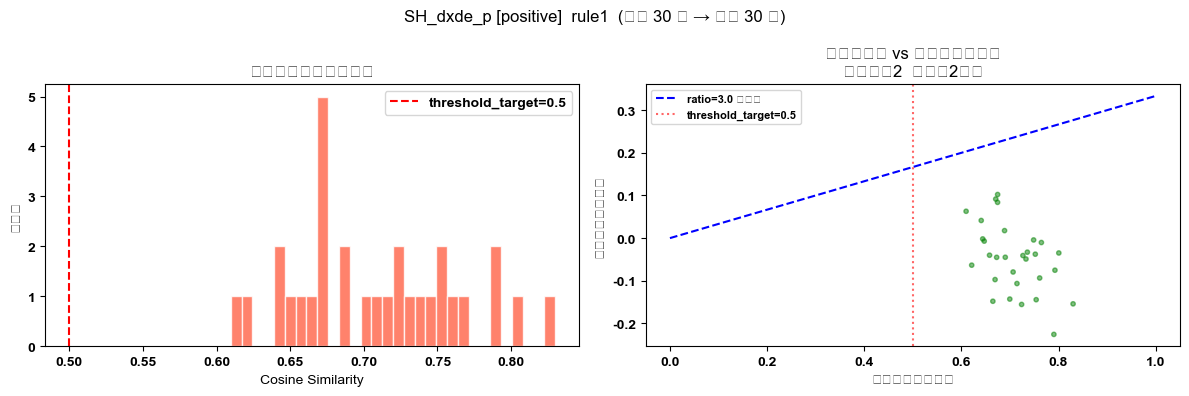

  ✅ SH_dxde_p rule1 分布图已保存: H:\limr\project\urine\results\clustering\fp_diagnostic_v2\SH_dxde_p\rule1_cell_sim_distribution.png


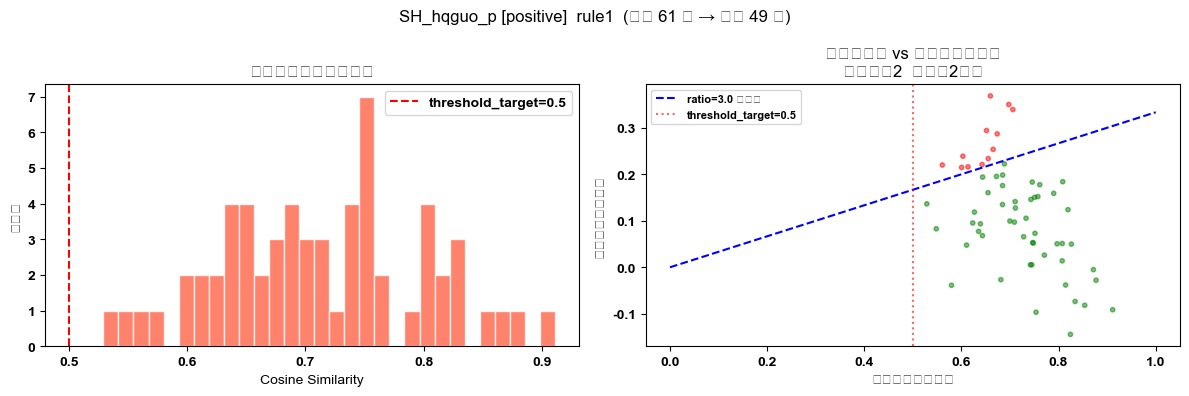

  ✅ SH_hqguo_p rule1 分布图已保存: H:\limr\project\urine\results\clustering\fp_diagnostic_v2\SH_hqguo_p\rule1_cell_sim_distribution.png


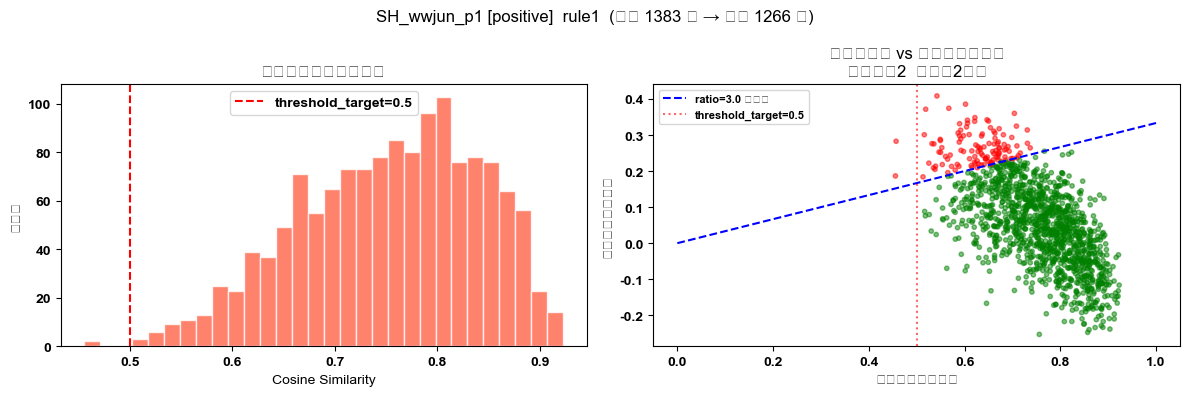

  ✅ SH_wwjun_p1 rule1 分布图已保存: H:\limr\project\urine\results\clustering\fp_diagnostic_v2\SH_wwjun_p1\rule1_cell_sim_distribution.png


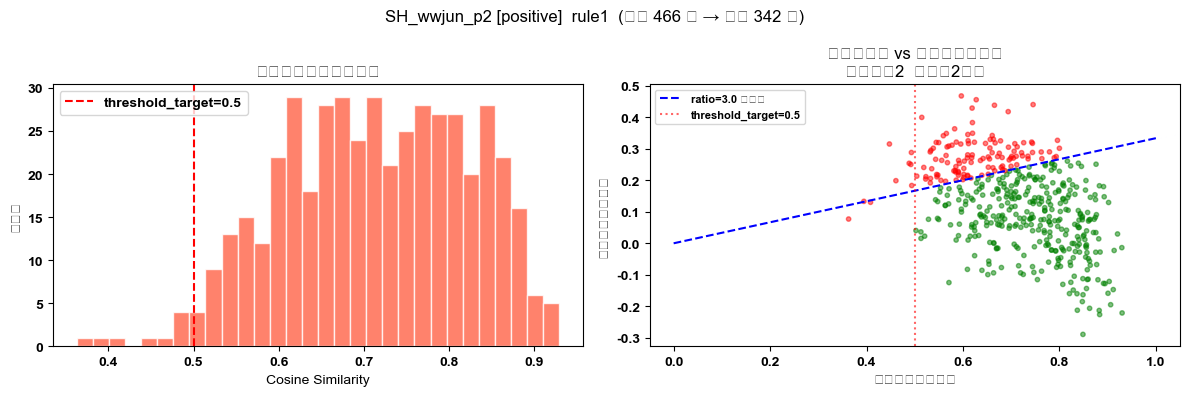

  ✅ SH_wwjun_p2 rule1 分布图已保存: H:\limr\project\urine\results\clustering\fp_diagnostic_v2\SH_wwjun_p2\rule1_cell_sim_distribution.png


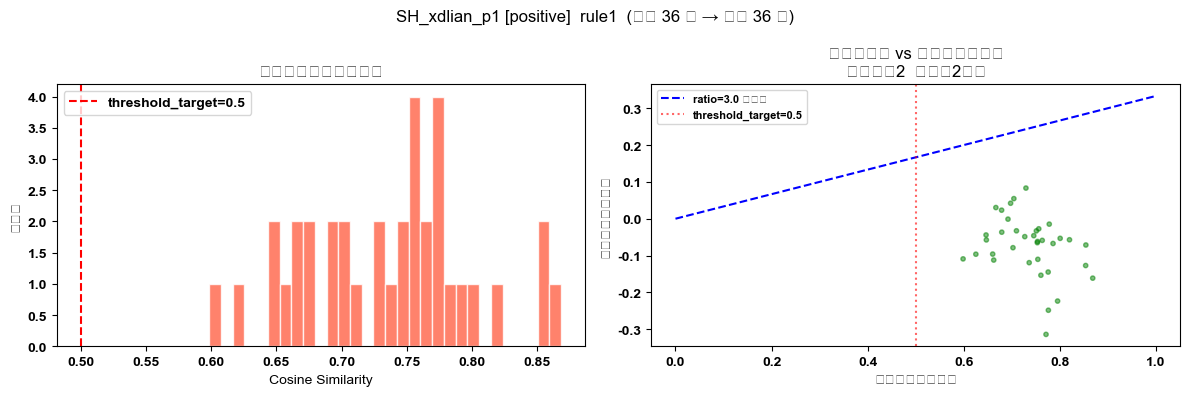

  ✅ SH_xdlian_p1 rule1 分布图已保存: H:\limr\project\urine\results\clustering\fp_diagnostic_v2\SH_xdlian_p1\rule1_cell_sim_distribution.png


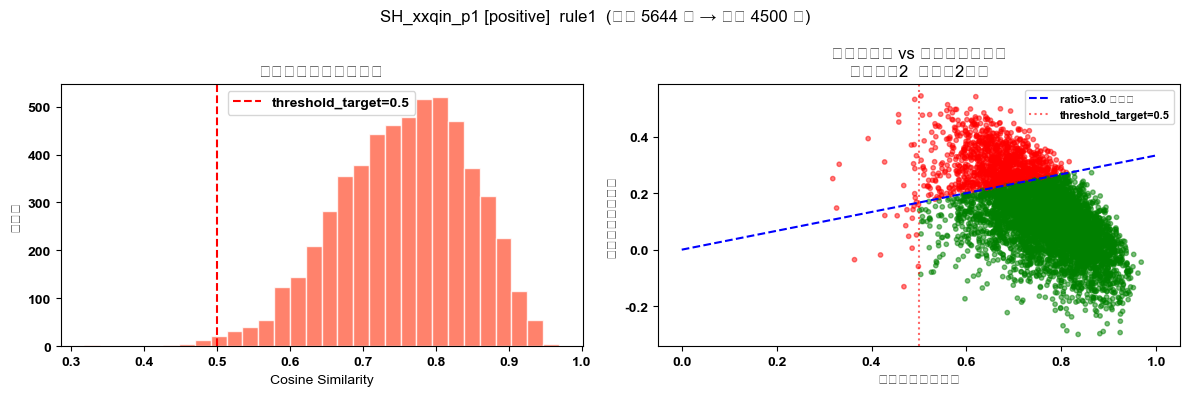

  ✅ SH_xxqin_p1 rule1 分布图已保存: H:\limr\project\urine\results\clustering\fp_diagnostic_v2\SH_xxqin_p1\rule1_cell_sim_distribution.png


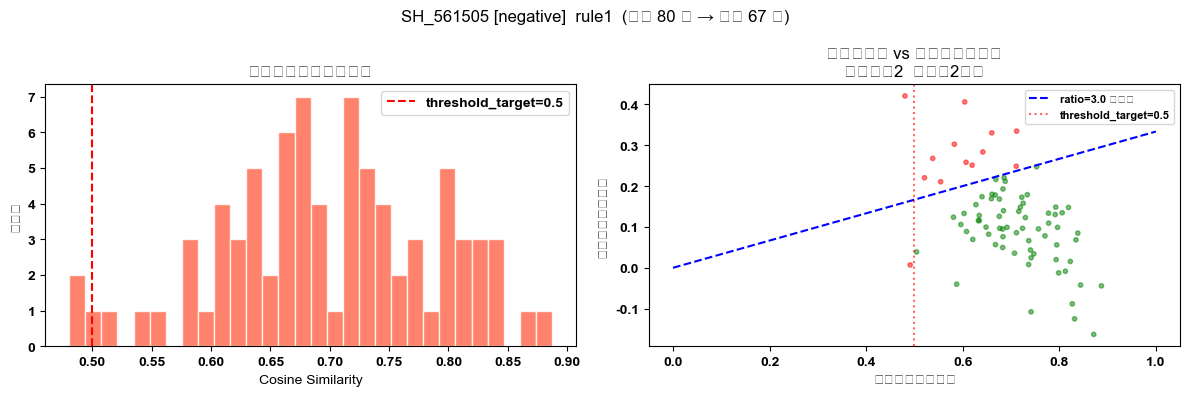

  ✅ SH_561505 rule1 分布图已保存: H:\limr\project\urine\results\clustering\fp_diagnostic_v2\SH_561505\rule1_cell_sim_distribution.png


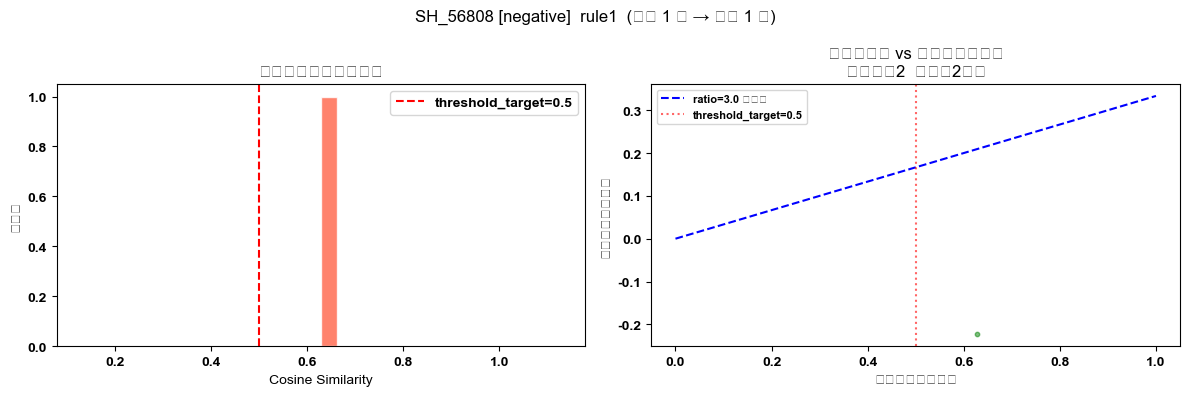

  ✅ SH_56808 rule1 分布图已保存: H:\limr\project\urine\results\clustering\fp_diagnostic_v2\SH_56808\rule1_cell_sim_distribution.png


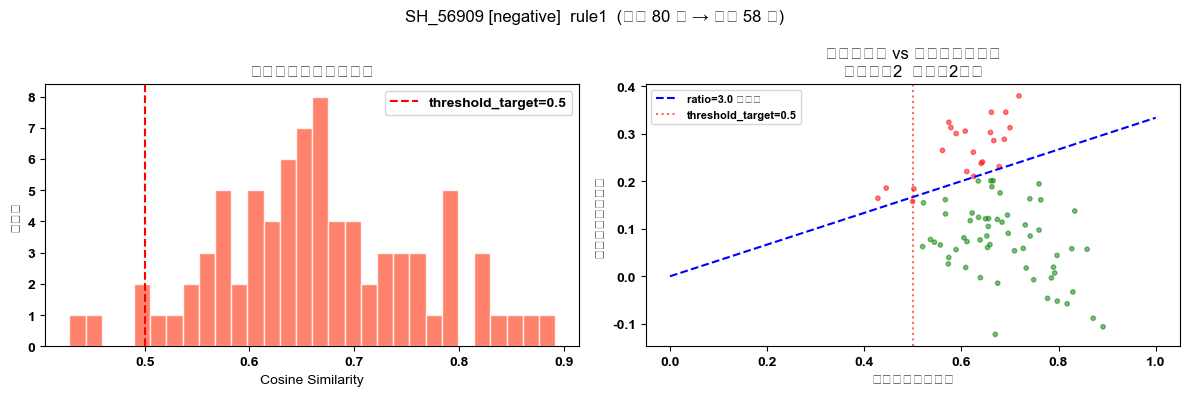

  ✅ SH_56909 rule1 分布图已保存: H:\limr\project\urine\results\clustering\fp_diagnostic_v2\SH_56909\rule1_cell_sim_distribution.png


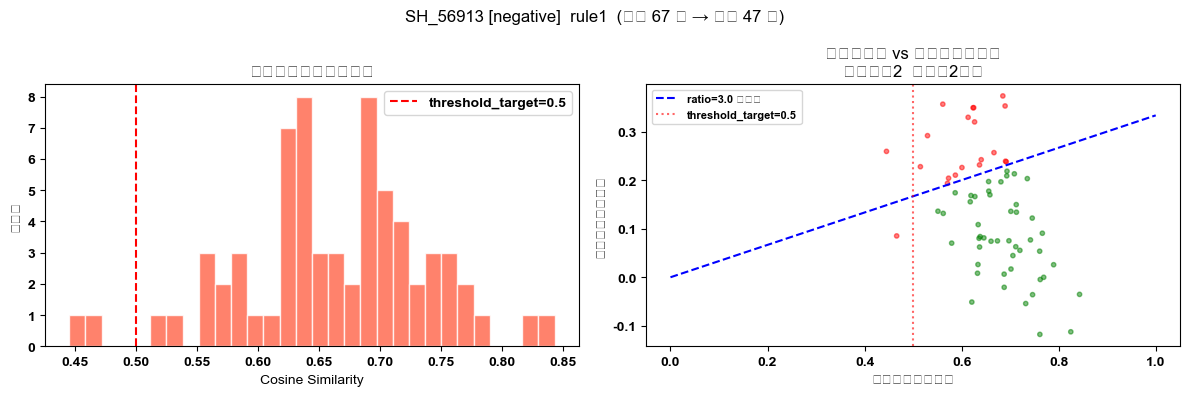

  ✅ SH_56913 rule1 分布图已保存: H:\limr\project\urine\results\clustering\fp_diagnostic_v2\SH_56913\rule1_cell_sim_distribution.png


In [ ]:
n_ref      = ref_results["n_clusters"]
benign_idx = [i for i in range(n_ref) if i not in MALIGNANT_REF_CLUSTERS]

for pid, pdata in all_patient_stats.items():
    status            = pdata["status"]
    rule_stats        = pdata["rule_stats"]
    cell_sims_p       = pdata["cell_sims"]
    rule_clusters_list = pdata["rule_clusters_list"]
    cand_labels       = pdata["cand_labels"]

    for rule_idx, (rule_name, stats) in enumerate(rule_stats.items()):
        if stats["total"] == 0:
            continue

        # 取出本规则输入的所有细胞索引
        all_indices = stats["_all_indices"]
        if not all_indices:
            continue

        mal_best_sims = []
        ben_max_sims  = []

        for idx in all_indices:
            sv = cell_sims_p[idx]
            mal_best_sims.append(float(sv[MALIGNANT_REF_CLUSTERS].max()))
            if benign_idx:
                ben_max_sims.append(float(sv[benign_idx].max()))

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        fig.suptitle(
            f"{pid} [{status}]  {rule_name}  "
            f"(输入 {stats['total']} 个 → 保留 {stats['passed']} 个)",
            fontsize=12
        )

        # 左图：最佳恶性相似度直方图
        axes[0].hist(mal_best_sims, bins=30, color="tomato", edgecolor="white", alpha=0.8)
        axes[0].axvline(CELL_THRESHOLD_TARGET, color="red", linestyle="--",
                        label=f"threshold_target={CELL_THRESHOLD_TARGET}")
        axes[0].set_title("Best Malignant Cluster Similarity Distribution")
        axes[0].set_xlabel("Cosine Similarity")
        axes[0].set_ylabel("Cell Count")
        axes[0].legend()

        # 右图：恶性相似度 vs 良性最大相似度散点图
        if ben_max_sims:
            passed_set = set(pdata["rule_stats"][rule_name].get("_all_indices", []))
            colors = [
                "green" if (m >= CELL_THRESHOLD_TARGET and m / CELL_THRESHOLD_RATIO > b)
                else "red"
                for m, b in zip(mal_best_sims, ben_max_sims)
            ]
            axes[1].scatter(mal_best_sims, ben_max_sims, c=colors, alpha=0.5, s=10)
            x_line = np.linspace(0, 1, 100)
            axes[1].plot(x_line, x_line / CELL_THRESHOLD_RATIO, "b--",
                         label=f"ratio={CELL_THRESHOLD_RATIO} 分界线")
            axes[1].axvline(CELL_THRESHOLD_TARGET, color="red", linestyle=":",
                            alpha=0.6, label=f"threshold_target={CELL_THRESHOLD_TARGET}")
            axes[1].set_title("Malignant vs Benign Max Similarity\n🟢Pass Layer 2  🔴Rejected by Layer 2")
            axes[1].set_xlabel("Best Malignant Cluster Similarity")
            axes[1].set_ylabel("Max Benign Cluster Similarity")
            axes[1].legend(fontsize=8)

        plt.tight_layout()
        fig_path = os.path.join(BASE_SAVE_DIR, pid,
                                f"{rule_name}_cell_sim_distribution.png")
        plt.savefig(fig_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"  ✅ {pid} {rule_name} 分布图已保存: {fig_path}")
